In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/iambahar/thesisdataset/merged.csv


In [5]:
!pip install pandas numpy scikit-learn shap matplotlib

Explainers setup complete! Commencing image rendering pipeline...

Processing plots for class: Acute...


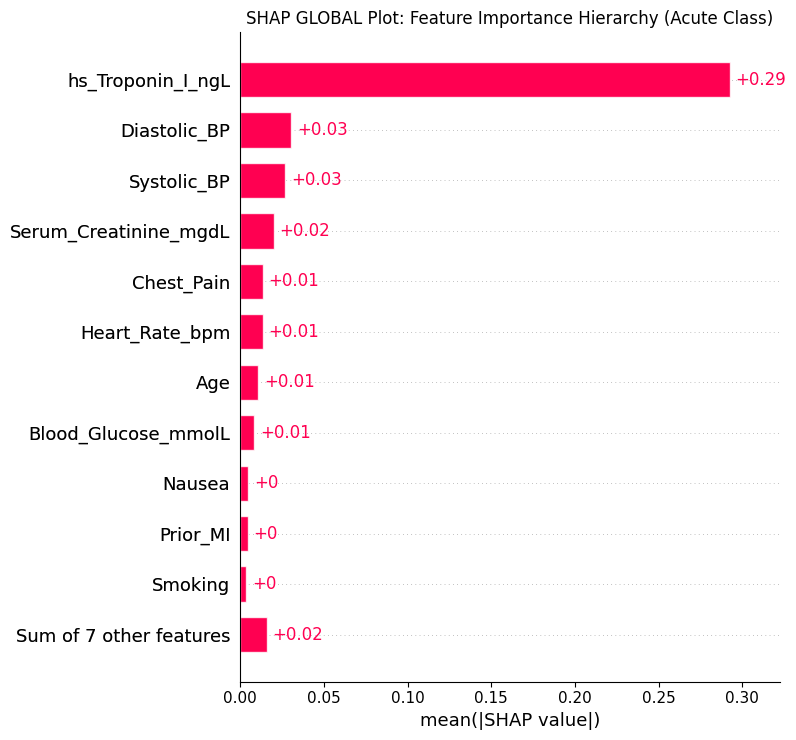

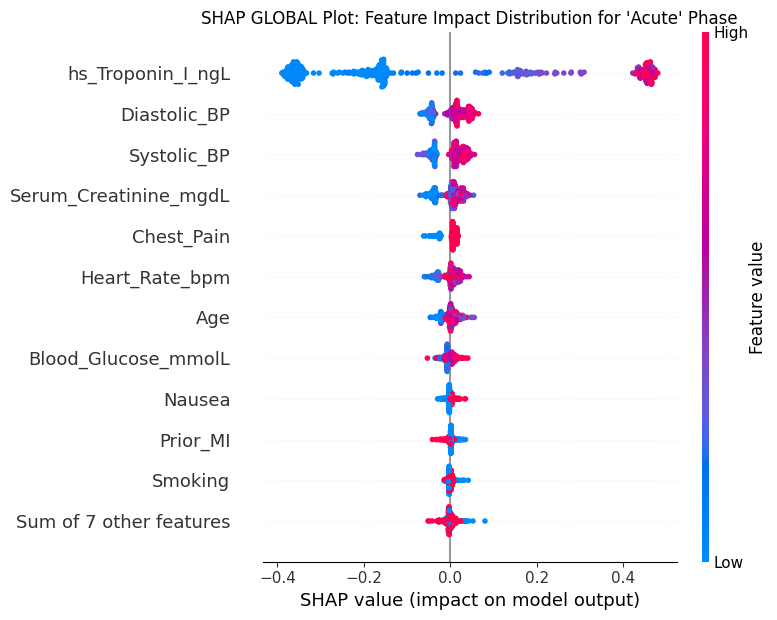

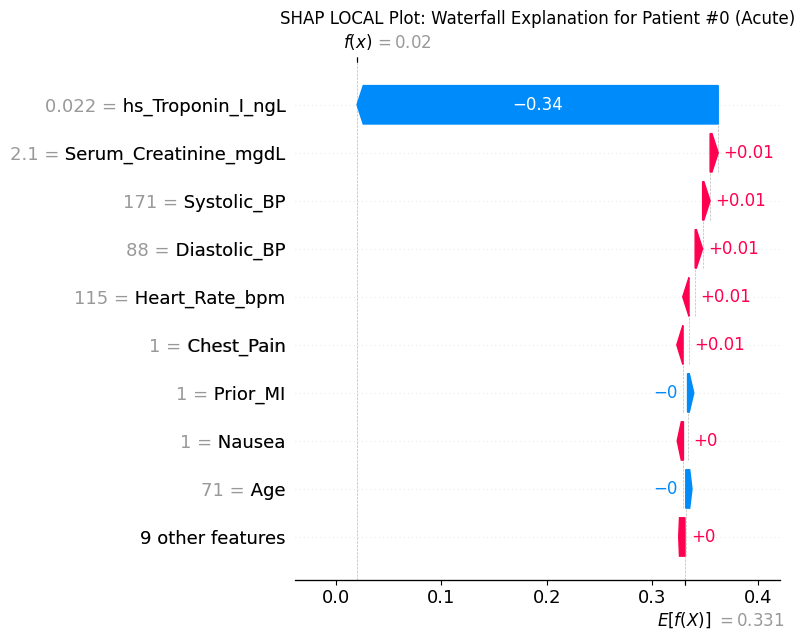

/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.

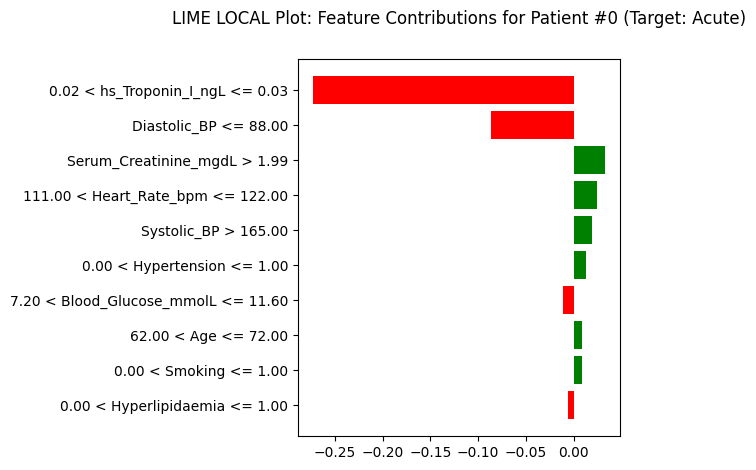

Processing plots for class: Chronic...


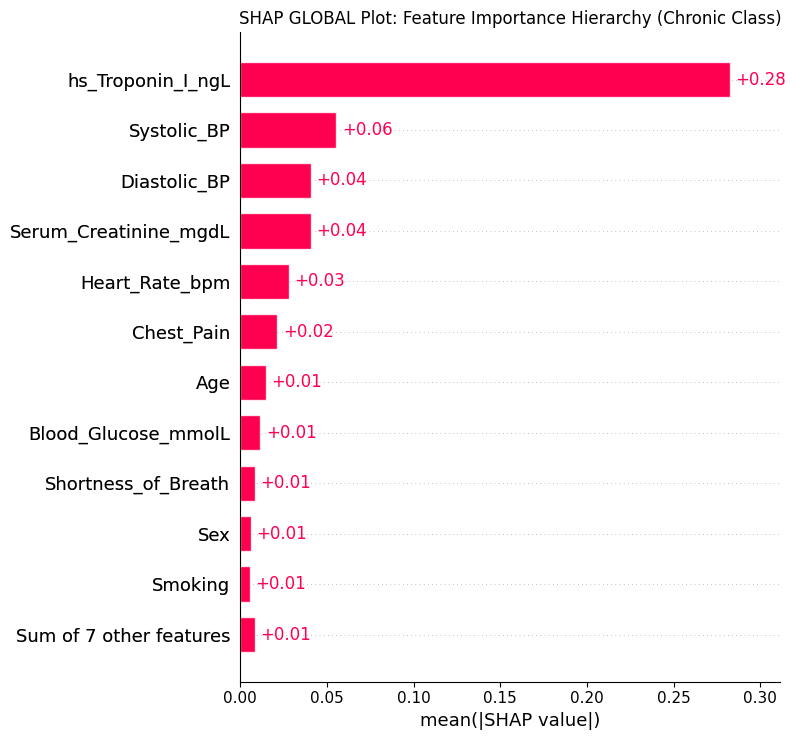

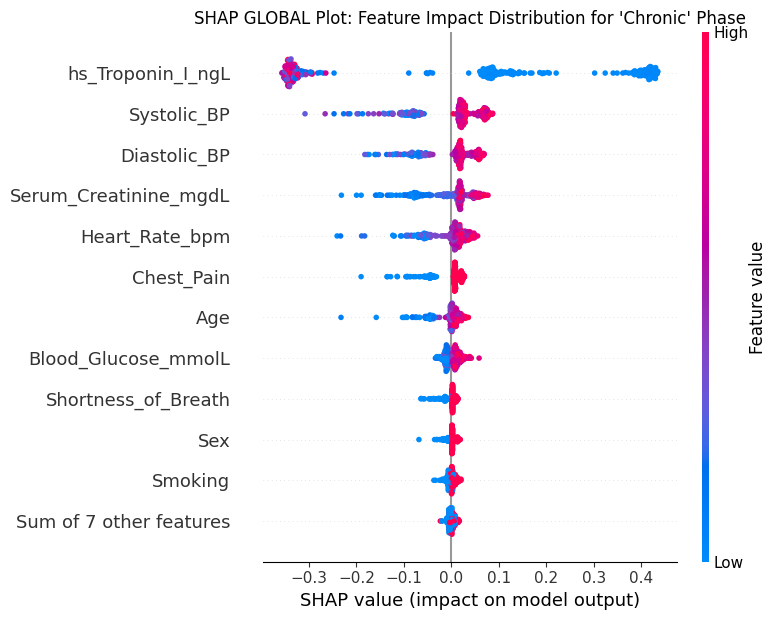

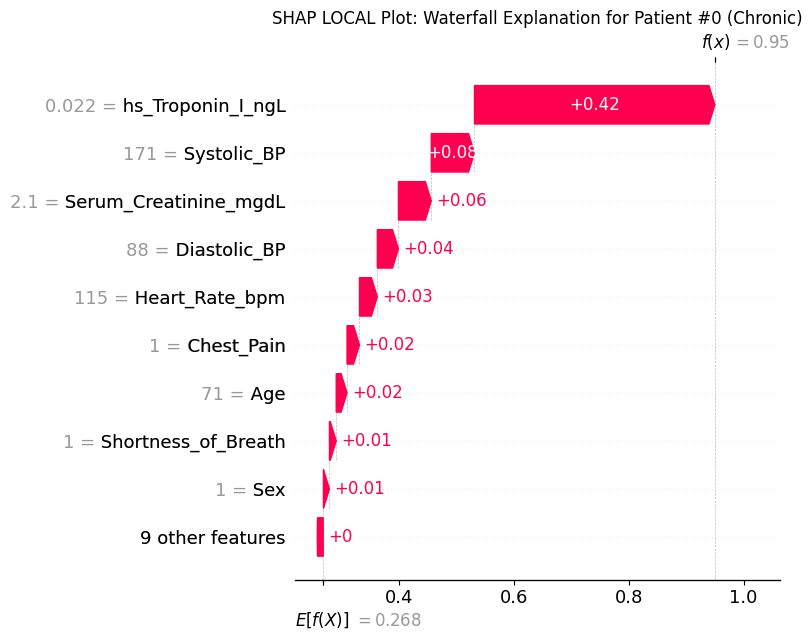

/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.

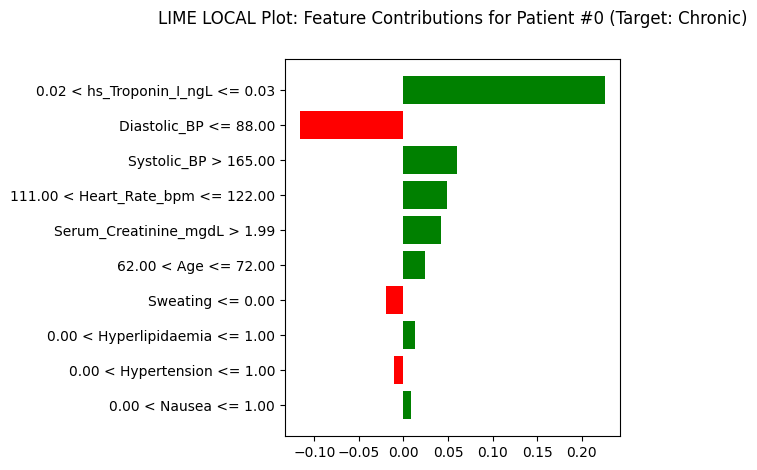

Processing plots for class: Non-MI...


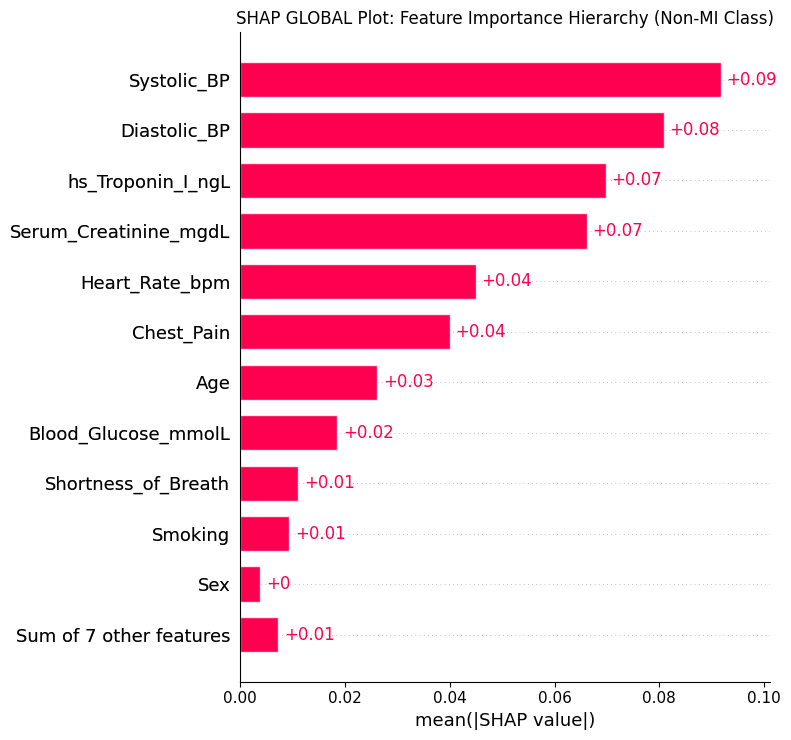

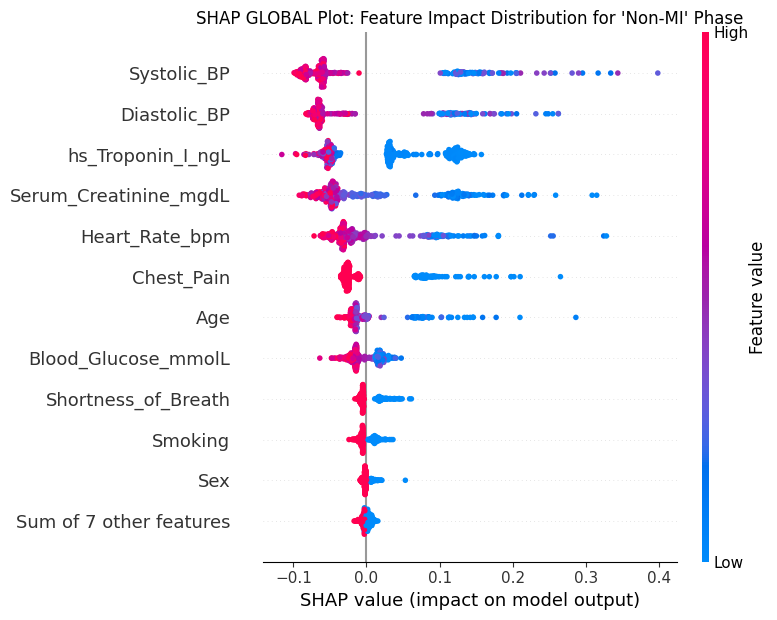

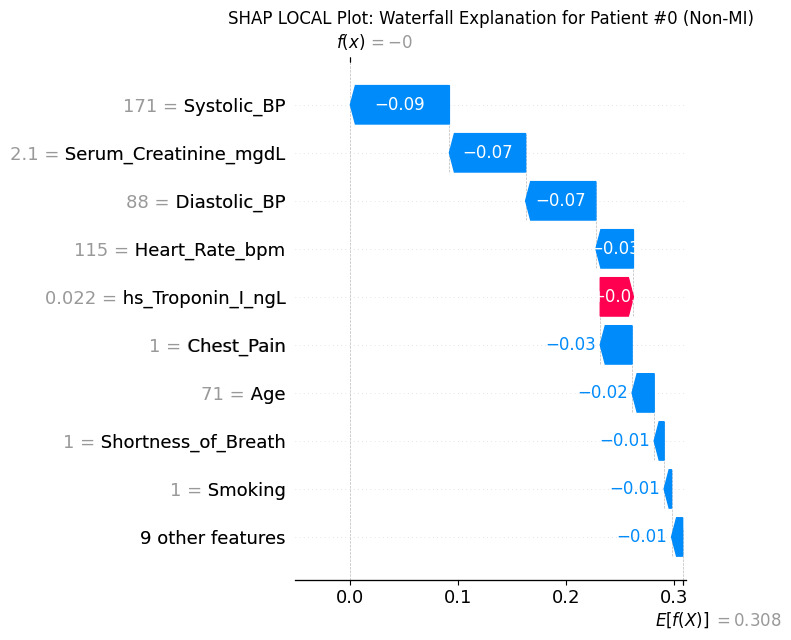

/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.

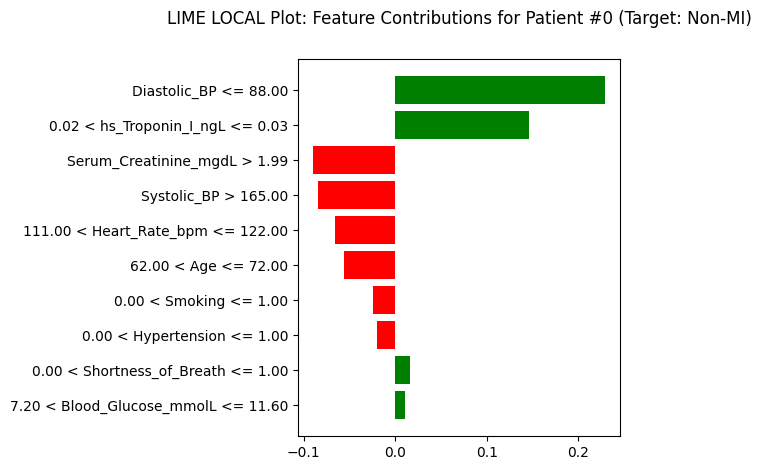

Processing plots for class: Sub-acute...


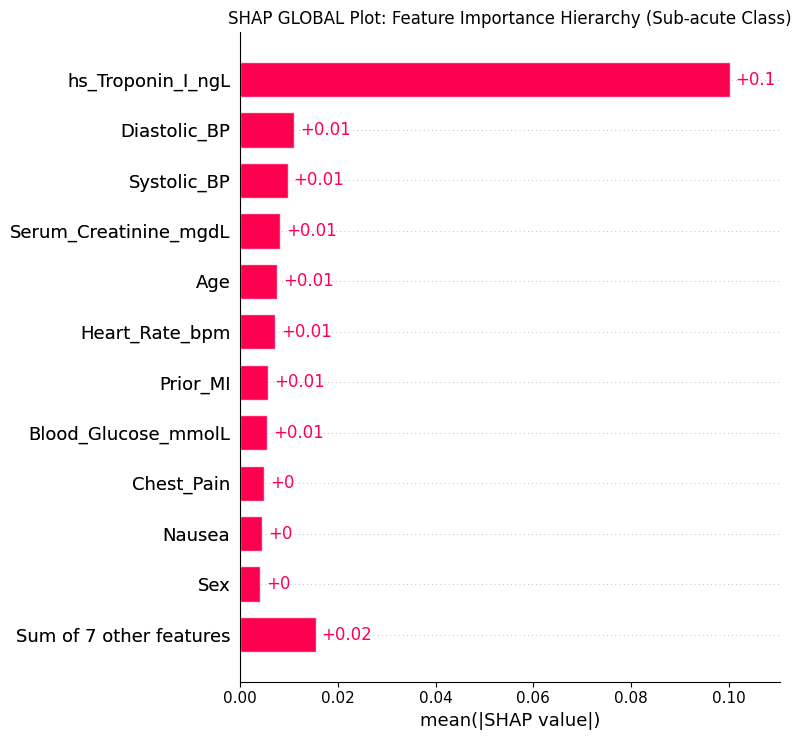

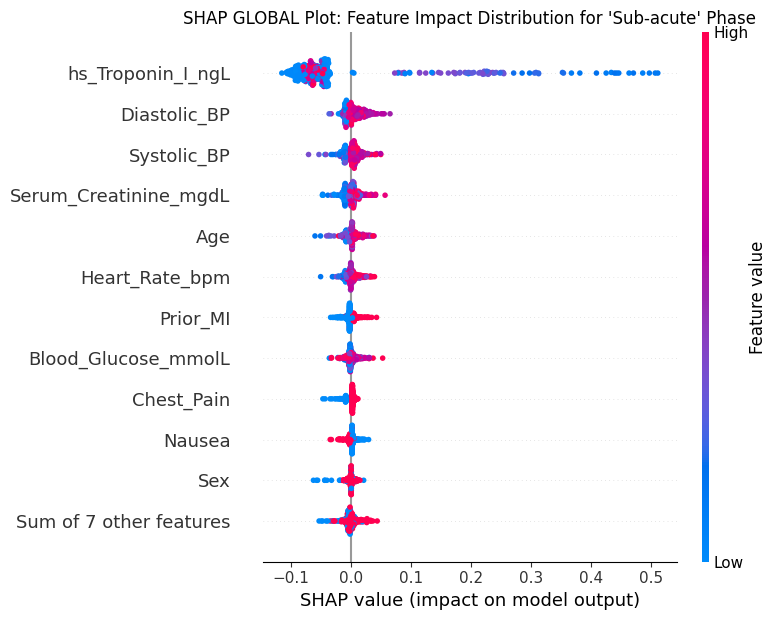

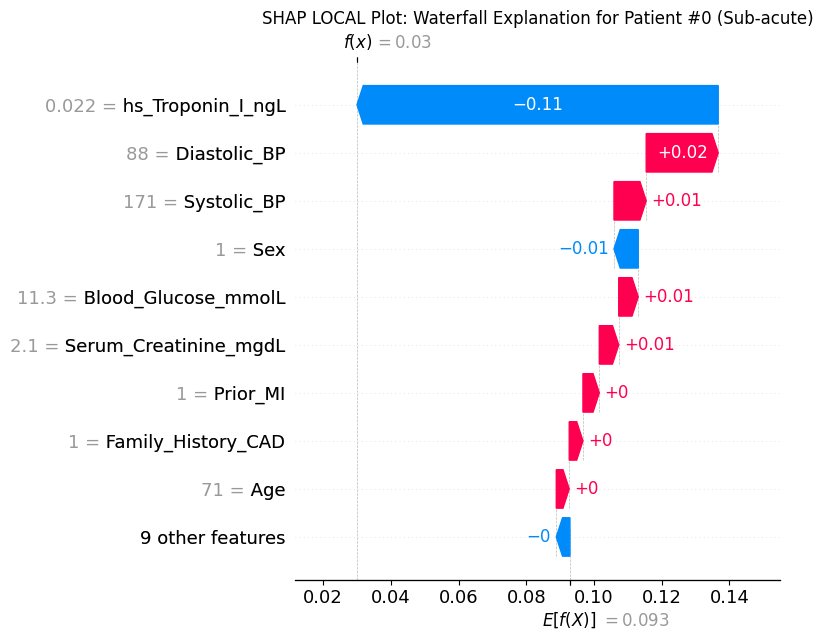

/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.

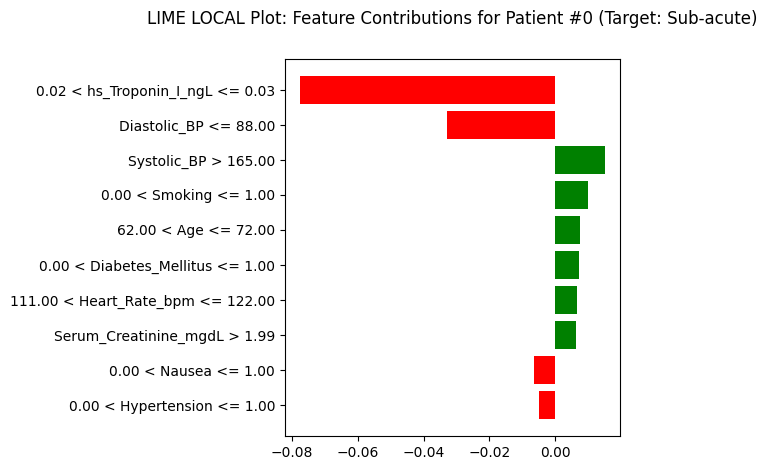


All plots rendered. Writing files into archive zip container...
Success! Download your zipped archive package directly here: /kaggle/working/thesis_xai_plots.zip


In [5]:
import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import shap
from lime import lime_tabular

# ==========================================
# 1. DIRECTORY CONFIGURATION & SETUP
# ==========================================
# Define path layout inside Kaggle's writable directory
output_dir = '/kaggle/working/thesis_plots'
os.makedirs(output_dir, exist_ok=True)

# ==========================================
# 2. DATA PREPROCESSING
# ==========================================
df = pd.read_csv('/kaggle/input/datasets/iambahar/thesisdataset/merged.csv')

# Split Blood Pressure into Systolic and Diastolic
df[['Systolic_BP', 'Diastolic_BP']] = df['Blood_Pressure_mmHg'].str.split('/', expand=True).astype(float)
df = df.drop(columns=['Blood_Pressure_mmHg'])

# Drop columns with extreme missingness (>85% missing values)
df = df.drop(columns=['CK_MB_UL', 'BNP_pgmL'])

# Impute minor missing data in Family History
df['Family_History_CAD'] = df['Family_History_CAD'].fillna('No')

# Encode categorical variables cleanly
cat_cols = ['Sex', 'Chest_Pain', 'Shortness_of_Breath', 'Nausea', 'Sweating', 
            'Hypertension', 'Diabetes_Mellitus', 'Smoking', 'Hyperlipidaemia', 
            'Prior_MI', 'Family_History_CAD']

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# Encode target variable (Phase)
le_target = LabelEncoder()
df['Phase'] = le_target.fit_transform(df['Phase'])
class_names = le_target.classes_ # ['Acute', 'Chronic', 'Non-MI', 'Sub-acute']

# Split features and target
X = df.drop(columns=['Phase'])
y = df['Phase']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ==========================================
# 3. MODEL TRAINING
# ==========================================
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# ==========================================
# 4. EXPLAINER SETUP (SHAP & LIME)
# ==========================================
explainer_shap = shap.TreeExplainer(model)
shap_values = explainer_shap(X_test)

explainer_lime = lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns,
    class_names=class_names,
    mode='classification',
    random_state=42
)

patient_index = 0  # Index of the specific patient to analyze locally
shap.initjs()

print("Explainers setup complete! Commencing image rendering pipeline...\n")

# ==========================================
# 5. GENERATE, SHOW, AND SAVE PLOTS
# ==========================================
for target_idx, class_name in enumerate(class_names):
    # Clean class name string for naming files safely
    safe_class_name = class_name.replace(" ", "_").replace("-", "_")
    print(f"Processing plots for class: {class_name}...")
    
    # --- [GLOBAL] SHAP Feature Importance Bar Plot ---
    plt.figure(figsize=(10, 5))
    shap.plots.bar(shap_values[:, :, target_idx], max_display=12, show=False) 
    plt.title(f"SHAP GLOBAL Plot: Feature Importance Hierarchy ({class_name} Class)")
    plt.tight_layout()
    plt.savefig(f"{output_dir}/shap_global_bar_{safe_class_name}.png", dpi=300)
    plt.show()
    plt.close()

    # --- [GLOBAL] SHAP Feature Effects Beeswarm Plot ---
    plt.figure(figsize=(10, 5))
    shap.plots.beeswarm(shap_values[:, :, target_idx], max_display=12, show=False)
    plt.title(f"SHAP GLOBAL Plot: Feature Impact Distribution for '{class_name}' Phase")
    plt.tight_layout()
    plt.savefig(f"{output_dir}/shap_global_beeswarm_{safe_class_name}.png", dpi=300)
    plt.show()
    plt.close()

    # --- [LOCAL] SHAP Waterfall Plot ---
    plt.figure(figsize=(10, 5))
    shap.plots.waterfall(shap_values[patient_index, :, target_idx], show=False)
    plt.title(f"SHAP LOCAL Plot: Waterfall Explanation for Patient #{patient_index} ({class_name})")
    plt.tight_layout()
    plt.savefig(f"{output_dir}/shap_local_waterfall_{safe_class_name}.png", dpi=300)
    plt.show()
    plt.close()

    # --- [LOCAL] LIME Contribution Chart ---
    lime_exp = explainer_lime.explain_instance(
        data_row=X_test.iloc[patient_index],
        predict_fn=model.predict_proba,
        num_features=10,
        labels=[target_idx]
    )
    fig_lime = lime_exp.as_pyplot_figure(label=target_idx)
    plt.title(f"LIME LOCAL Plot: Feature Contributions for Patient #{patient_index} (Target: {class_name})", pad=25)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/lime_local_pyplot_{safe_class_name}.png", dpi=300)
    plt.show()
    plt.close()

# ==========================================
# 6. ARCHIVE GENERATED IMAGES INTO A ZIP
# ==========================================
zip_path = '/kaggle/working/thesis_xai_plots.zip'

print("\nAll plots rendered. Writing files into archive zip container...")
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(output_dir):
        for file in files:
            # Add files to zip relative to the baseline directory
            full_file_path = os.path.join(root, file)
            zipf.write(full_file_path, arcname=file)

print(f"Success! Download your zipped archive package directly here: {zip_path}")

In [2]:
!pip install lime

In [17]:
# ==============================================================================
# STEP 0: Install and Import QLattice Framework (Feyn)
# ==============================================================================
!pip install -q feyn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import feyn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Set random seeds for clinical reproducibility
np.random.seed(42)

# Global dictionary to prevent notebook logs from swallowing your results
FINAL_THESIS_REPORT = {
    "binary_metrics": {},
    "binary_formula": "",
    "multiclass_metrics": {},
    "multiclass_formulas": {},
    "multiclass_report": ""
}

# ==============================================================================
# PART 1: Dataset Loading & Feature Engineering (Pandas-Native)
# ==============================================================================
file_path = "/kaggle/input/datasets/iambahar/thesisdataset/merged.csv" 
df_raw = pd.read_csv(file_path)
df_raw.columns = df_raw.columns.str.strip()
df_raw['Phase'] = df_raw['Phase'].astype(str).str.strip()
df_raw = df_raw[(df_raw['Phase'] != 'nan') & (df_raw['Phase'] != '')]

# Custom Filter: Exclude rows where CK-MB or BNP biomarker entries are present
if 'CK_MB_UL' in df_raw.columns:
    df_raw = df_raw[df_raw['CK_MB_UL'].isna()]
if 'BNP_pgmL' in df_raw.columns:
    df_raw = df_raw[df_raw['BNP_pgmL'].isna()]
df_raw = df_raw.drop(columns=[col for col in ['CK_MB_UL', 'BNP_pgmL'] if col in df_raw.columns])

# Parse Blood Pressure strings into separate numeric properties
if 'Blood_Pressure_mmHg' in df_raw.columns:
    bp_split = df_raw['Blood_Pressure_mmHg'].astype(str).str.split('/', expand=True)
    df_raw['Systolic_BP'] = pd.to_numeric(bp_split[0], errors='coerce')
    df_raw['Diastolic_BP'] = pd.to_numeric(bp_split[1], errors='coerce')
    df_raw = df_raw.drop(columns=['Blood_Pressure_mmHg'])

# Label encode categorical columns cleanly
cat_cols = ['Sex', 'Chest_Pain', 'Shortness_of_Breath', 'Nausea', 'Sweating', 
            'Hypertension', 'Diabetes_Mellitus', 'Smoking', 'Hyperlipidaemia', 
            'Prior_MI', 'Family_History_CAD']

for col in cat_cols:
    if col in df_raw.columns:
        le = LabelEncoder()
        df_raw[col] = le.fit_transform(df_raw[col].astype(str))

# Clinical specificity helper
def calculate_specificity(y_true, y_pred, is_binary=True):
    cm = confusion_matrix(y_true, y_pred)
    if is_binary:
        tn, fp, fn, tp = cm.ravel()
        return tn / (tn + fp) if (tn + fp) > 0 else 0.0
    else:
        specificities = []
        for i in range(cm.shape[0]):
            tp = cm[i, i]
            fn = np.sum(cm[i, :]) - tp
            fp = np.sum(cm[:, i]) - tp
            tn = np.sum(cm) - (tp + fn + fp)
            spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
            specificities.append(spec)
        return np.mean(specificities)

# Initialize the QLattice Simulator
ql = feyn.QLattice(random_seed=42)

# ==============================================================================
# PART 2: Task 1 - Binary QLattice Execution (Acute vs Rest)
# ==============================================================================
df_b = df_raw.copy()
df_b['target'] = df_b['Phase'].apply(lambda x: 1 if x == 'Acute' else 0).astype(int)

test_dfs_b = []
for label in [0, 1]:
    sampled_b = df_b[df_b['target'] == label].sample(n=70, random_state=42)
    test_dfs_b.append(sampled_b)

df_test_b = pd.concat(test_dfs_b)
df_train_b = df_b.drop(df_test_b.index)

train_data_b = df_train_b.drop(columns=['Phase'])
test_data_b = df_test_b.drop(columns=['Phase'])

models_b = ql.auto_run(train_data_b, output_name='target', criterion='bic')
best_model_b = models_b[0]

y_pred_b_prob = best_model_b.predict(test_data_b)
y_pred_b = (y_pred_b_prob > 0.5).astype(int)
y_test_b = test_data_b['target'].values

# Store values inside final dictionary
FINAL_THESIS_REPORT["binary_metrics"] = {
    "Accuracy": accuracy_score(y_test_b, y_pred_b),
    "Precision": precision_score(y_test_b, y_pred_b),
    "Sensitivity": recall_score(y_test_b, y_pred_b),
    "Specificity": calculate_specificity(y_test_b, y_pred_b, is_binary=True),
    "F1-Score": f1_score(y_test_b, y_pred_b)
}
FINAL_THESIS_REPORT["binary_formula"] = str(best_model_b.sympify())


# ==============================================================================
# PART 3: Task 2 - Multi-Class Execution via Fixed One-vs-Rest (OvR)
# ==============================================================================
df_m = df_raw.copy()
unique_phases = sorted(df_m['Phase'].unique())
phase_to_idx = {phase: i for i, phase in enumerate(unique_phases)}
df_m['class_idx'] = df_m['Phase'].map(phase_to_idx).astype(int)

test_dfs_m = []
for label_idx in range(len(unique_phases)):
    sampled_m = df_m[df_m['class_idx'] == label_idx].sample(n=70, random_state=42)
    test_dfs_m.append(sampled_m)

df_test_m = pd.concat(test_dfs_m)
df_train_m = df_m.drop(df_test_m.index)

X_test_m_features = df_test_m.drop(columns=['Phase', 'class_idx'])
y_test_multi = df_test_m['class_idx'].values

ovr_test_probs = {}

for phase in unique_phases:
    train_data_local = df_train_m.drop(columns=['Phase', 'class_idx']).copy()
    train_data_local['target'] = df_train_m['Phase'].apply(lambda x: 1 if x == phase else 0).astype(int)
    
    test_data_local = X_test_m_features.copy()
    test_data_local['target'] = df_test_m['Phase'].apply(lambda x: 1 if x == phase else 0).astype(int)
    
    models_m = ql.auto_run(train_data_local, output_name='target', criterion='bic')
    best_model_m = models_m[0]
    
    ovr_test_probs[phase] = best_model_m.predict(test_data_local)
    FINAL_THESIS_REPORT["multiclass_formulas"][phase] = str(best_model_m.sympify())

prob_matrix = np.column_stack([ovr_test_probs[phase] for phase in unique_phases])
y_pred_multi = np.argmax(prob_matrix, axis=1)

FINAL_THESIS_REPORT["multiclass_metrics"] = {
    "Accuracy": accuracy_score(y_test_multi, y_pred_multi),
    "Macro-Precision": precision_score(y_test_multi, y_pred_multi, average='macro'),
    "Macro-Sensitivity": recall_score(y_test_multi, y_pred_multi, average='macro'),
    "Macro-Specificity": calculate_specificity(y_test_multi, y_pred_multi, is_binary=False),
    "Macro-F1-Score": f1_score(y_test_multi, y_pred_multi, average='macro')
}
FINAL_THESIS_REPORT["multiclass_report"] = classification_report(y_test_multi, y_pred_multi, target_names=unique_phases)


# ==============================================================================
# PART 4: THE UNBROKEN PRINT BLOCK (Dumps everything at once at the very end)
# ==============================================================================
print("\n" + "="*80)
print("                  FINAL QLATTICE COMPREHENSIVE THESIS REPORT")
print("="*80)

print("\n### 1. BINARY CLASSIFICATION PERFORMANCE (ACUTE VS REST) ###")
for metric_name, val in FINAL_THESIS_REPORT["binary_metrics"].items():
    print(f"{metric_name:<20}: {val:.4f}")

print("\n>>> CRITICAL DERIVED BINARY FORMULA:")
print(f"  {FINAL_THESIS_REPORT['binary_formula']}")
print("-" * 80)

print("\n### 2. MULTI-CLASS PERFORMANCE CONSOLIDATED (4 PHASES) ###")
for metric_name, val in FINAL_THESIS_REPORT["multiclass_metrics"].items():
    print(f"{metric_name:<20}: {val:.4f}")

print("\nDetailed Multi-Class Breakdown:")
print(FINAL_THESIS_REPORT["multiclass_report"])
print("-" * 80)

print("\n>>> CRITICAL DERIVED MULTI-CLASS FORMULAS FOR EACH PHASE:")
for phase_name, formula_str in FINAL_THESIS_REPORT["multiclass_formulas"].items():
    print(f"  * Phase [{phase_name:<10}] Formula -> {formula_str}")

print("\n" + "="*80)
print("                             END OF REPORT")
print("="*80)


                  FINAL QLATTICE COMPREHENSIVE THESIS REPORT

### 1. BINARY CLASSIFICATION PERFORMANCE (ACUTE VS REST) ###
Accuracy            : 0.9429
Precision           : 0.9189
Sensitivity         : 0.9714
Specificity         : 0.9143
F1-Score            : 0.9444

>>> CRITICAL DERIVED BINARY FORMULA:
  logreg(1.769*log(-0.421961*Sex + 5.33216*hsTroponinIngL - 0.176246) + 1.14394)
--------------------------------------------------------------------------------

### 2. MULTI-CLASS PERFORMANCE CONSOLIDATED (4 PHASES) ###
Accuracy            : 0.7964
Macro-Precision     : 0.8274
Macro-Sensitivity   : 0.7964
Macro-Specificity   : 0.9321
Macro-F1-Score      : 0.7593

Detailed Multi-Class Breakdown:
              precision    recall  f1-score   support

       Acute       0.62      0.96      0.75        70
     Chronic       0.85      1.00      0.92        70
      Non-MI       0.99      0.99      0.99        70
   Sub-acute       0.85      0.24      0.38        70

    accuracy         

In [ ]:
# diceml, qlattice, counterfactual